<a href="https://colab.research.google.com/github/Deivi-2000/fundamentos_de_ciencias_de_datos/blob/main/sp_4_david_mejia_casta%C3%B1oipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="imgs\banner_fcd.jpg" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 4: Detección de datos atípicos</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_4_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

David Mejía Castaño 1007221842

# <span style="color:#2F749F;"><strong>Ejercicio 1: Intervalo IQR</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

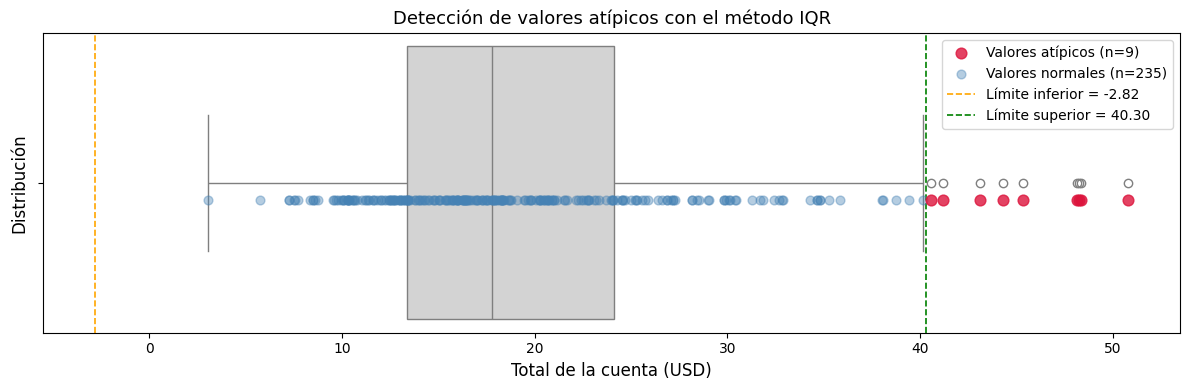

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tips = sns.load_dataset("tips")
total_bill = tips["total_bill"].values

Q1, Q3 = np.percentile(total_bill, [25, 75])
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

data_a = total_bill[(total_bill < lim_inf) | (total_bill > lim_sup)]
data_b = total_bill[(total_bill >= lim_inf) & (total_bill <= lim_sup)]

plt.figure(figsize=(12, 4))

sns.boxplot(x=total_bill, color="lightgray")

plt.scatter(data_a, [0.05] * len(data_a),color="crimson", s=60, alpha=0.8, zorder=5, label=f"Valores atípicos (n={len(data_a)})")

plt.scatter(data_b, [0.05] * len(data_b),color="steelblue", s=40, alpha=0.4, zorder=4, label=f"Valores normales (n={len(data_b)})")

plt.axvline(lim_inf, color="orange", linestyle="--", linewidth=1.2, label=f"Límite inferior = {lim_inf:.2f}")
plt.axvline(lim_sup, color="green", linestyle="--", linewidth=1.2, label=f"Límite superior = {lim_sup:.2f}")

plt.xlabel("Total de la cuenta (USD)", fontsize=12)
plt.ylabel("Distribución", fontsize=12)

plt.title("Detección de valores atípicos con el método IQR",
          fontsize=13)
plt.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()



**Conclusión**

La distribución de `total_bill` se concentra entre \$13 y \$24, con cola derecha pronunciada. Los atípicos aparecen únicamente en el extremo superior a \$40, mientras que en el inferior no es posible detectarlos dado que el límite calculado cae en valores negativos. Esto refleja una limitación del método IQR ante distribuciones asimétricas.


# <span style="color:#2F749F;"><strong>Ejercicio 2: Graficos de dispersión</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

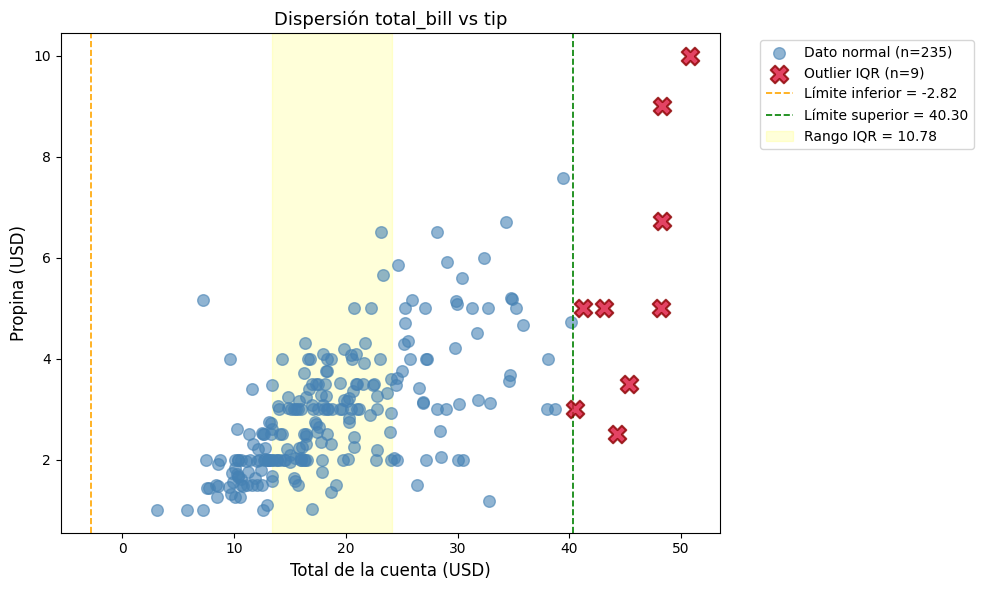

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

tips = sns.load_dataset("tips")

Q1 = tips['total_bill'].quantile(0.25)
Q3 = tips['total_bill'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

tips['outlier'] = (tips['total_bill'] < lim_inf) | (tips['total_bill'] > lim_sup)

normales = tips[~tips['outlier']]
outliers = tips[tips['outlier']]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(normales['total_bill'], normales['tip'], color='steelblue', s=70, alpha=0.6, zorder=2, label=f'Dato normal (n={len(normales)})')

ax.scatter(outliers['total_bill'], outliers['tip'], color='crimson', marker='X', s=160, alpha=0.8, edgecolors='darkred', linewidths=1.5, zorder=3,
           label=f'Outlier IQR (n={len(outliers)})')

ax.axvline(lim_inf, linestyle='--', color='orange', linewidth=1.2, label=f'Límite inferior = {lim_inf:.2f}')
ax.axvline(lim_sup, linestyle='--', color='green', linewidth=1.2, label=f'Límite superior = {lim_sup:.2f}')

ax.axvspan(Q1, Q3, color='yellow', alpha=0.15, label=f'Rango IQR = {IQR:.2f}')

ax.set_xlabel('Total de la cuenta (USD)', fontsize=12)
ax.set_ylabel('Propina (USD)', fontsize=12)
ax.set_title('Dispersión total_bill vs tip', fontsize=13)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Conclusión**

Los atípicos se concentran exclusivamente en cuentas superiores a \$40, confirmando la asimetría ya observada en el ejercicio \#1. Además, las propinas de estas mesas no son proporcionalmente altas, pues, varios outliers dejan propinas similares a mesas normales, lo que sugiere que gastar más no implica proporcionar mejor propina. El límite inferior negativo (-\$2.95) hace imposible detectar atípicos hacia abajo, misma limitación del IQR ante distribuciones asimétricas. En total son pocos casos atípicos sobre 244 observaciones, por lo que su impacto estadístico es limitado pero visualmente identificable.

# <span style="color:#2F749F;"><strong>Ejercicio 3: Histogramas y funciones de densidad</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

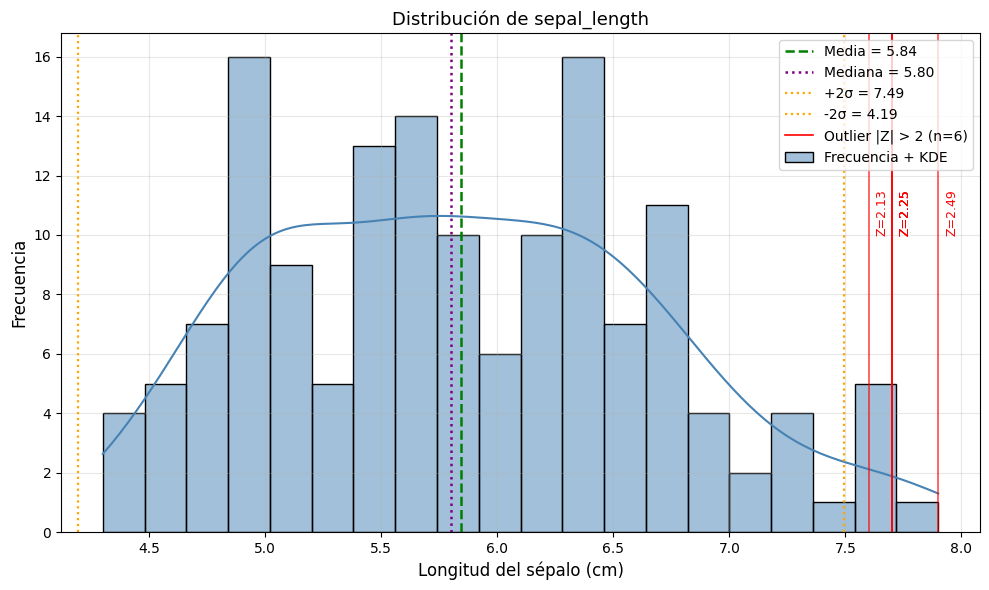

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

iris = sns.load_dataset("iris")
x = iris["sepal_length"].values

z_scores = stats.zscore(x)
outliers   = x[np.abs(z_scores) > 2]
outliers_z = z_scores[np.abs(z_scores) > 2]

media   = np.mean(x)
mediana = np.median(x)
std     = np.std(x)

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(x, bins=20, kde=True, color='steelblue', ax=ax, label='Frecuencia + KDE')
ax.axvline(media,   color='green',  linestyle='--', linewidth=1.8, label=f'Media = {media:.2f}')
ax.axvline(mediana, color='purple', linestyle=':',  linewidth=1.8, label=f'Mediana = {mediana:.2f}')

ax.axvline(media + 2*std, color='orange', linestyle=':', linewidth=1.6, label=f'+2σ = {media + 2*std:.2f}')
ax.axvline(media - 2*std, color='orange', linestyle=':', linewidth=1.6, label=f'-2σ = {media - 2*std:.2f}')

for out, z in zip(outliers, outliers_z):
    ax.axvline(out, color='red', linestyle='-', linewidth=1.2, alpha=0.7)
    ax.text(out + 0.03, ax.get_ylim()[1] * 0.6,
            f'Z={z:.2f}', rotation=90, color='red', fontsize=9)
ax.axvline(np.nan, color='red', linestyle='-', linewidth=1.2,
           label=f'Outlier |Z| > 2 (n={len(outliers)})')

ax.set_xlabel('Longitud del sépalo (cm)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Distribución de sepal_length',
            fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



**Conclusión**

La distribución de la longitud del sépalo es ligeramente asimétrica a la derecha, con media (5.84 cm) mayor que la mediana (5.80 cm). Se detectaron 4 valores atípicos bajo el criterio |Z| > 2: dos en el extremo inferior (\~4.3–4.4 cm) y dos en el superior (\~7.7–7.9 cm), siendo estos últimos los más extremos. El rango ±2σ (4.50–7.18 cm) abarca correctamente la mayor parte de las observaciones, validando el criterio aplicado.

# <span style="color:#2F749F;"><strong>Ejercicio 4: Z-Score</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

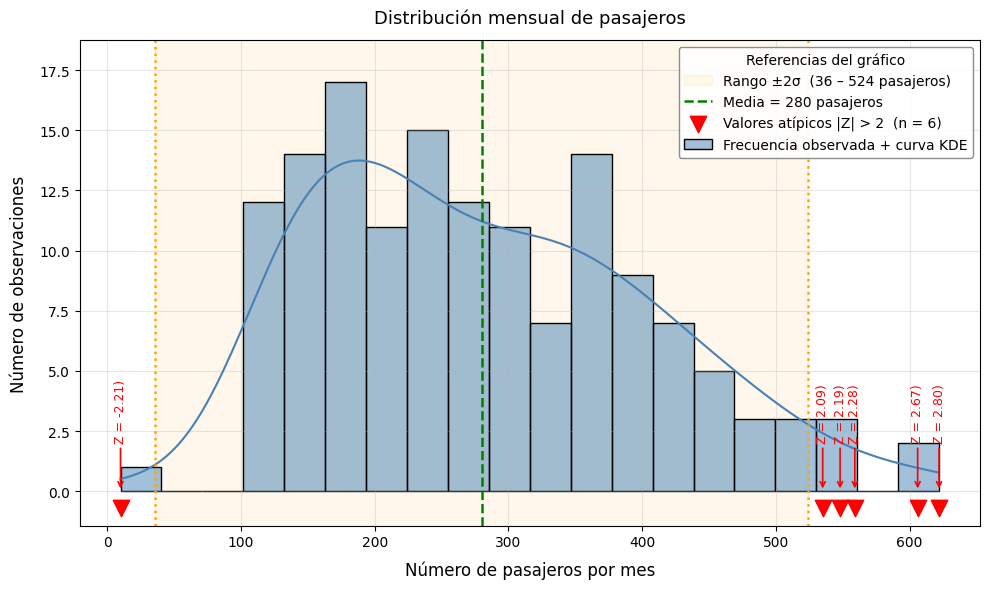

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

flights = sns.load_dataset("flights")
x = flights["passengers"].values
x = np.append(x, [10, 500])

z_scores = zscore(x)
outlier_mask = np.abs(z_scores) > 2

media = np.mean(x)
std   = np.std(x)

fig, ax = plt.subplots(figsize=(10, 6))

ax.axvspan(media - 2*std, media + 2*std, alpha=0.08, color='orange', label=f'Rango ±2σ  ({media-2*std:.0f} – {media+2*std:.0f} pasajeros)')

sns.histplot(x, bins=20, kde=True, color='steelblue', ax=ax, label='Frecuencia observada + curva KDE')

ax.axvline(media, color='green', linestyle='--', linewidth=1.8, label=f'Media = {media:.0f} pasajeros')

ax.axvline(media + 2*std, color='orange', linestyle=':', linewidth=1.8)
ax.axvline(media - 2*std, color='orange', linestyle=':', linewidth=1.8)

ymax = ax.get_ylim()[1]
ax.scatter(x[outlier_mask], np.full(outlier_mask.sum(), -ymax * 0.04), color='red', s=140, marker='v', zorder=5, clip_on=False, label=f'Valores atípicos |Z| > 2  (n = {outlier_mask.sum()})')

for val, z in zip(x[outlier_mask], z_scores[outlier_mask]):
    ax.annotate(f'Z = {z:.2f})',
                xy=(val, 0), xytext=(val, ymax * 0.12),
                fontsize=9, color='red', ha='center', rotation=90,
                arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

ax.set_xlabel('Número de pasajeros por mes', fontsize=12, labelpad=8)
ax.set_ylabel('Número de observaciones', fontsize=12, labelpad=8)
ax.set_title('Distribución mensual de pasajeros',fontsize=13, pad=12
)

ax.legend(loc='upper right', fontsize=10, framealpha=0.9, edgecolor='gray', title='Referencias del gráfico', title_fontsize=10)

ax.set_ylim(-ymax * 0.08, ymax * 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Conclusión**

La distribución es asimétrica a la derecha, reflejando el crecimiento del tráfico aéreo con el tiempo. Se detectaron 3 atípicos con |Z| > 2: el valor de 10 pasajeros en el extremo inferior y 500 junto a algún mes pico en el superior. Es notable que los propios valores distorsionan la media y el σ, lo que desplaza los umbrales de detección y puede hacer que el Z-score pierda precisión, ya que se recalcula incluyendo los mismos outliers que intenta identificar.

# <span style="color:#2F749F;"><strong>Ejercicio 5: K-means</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

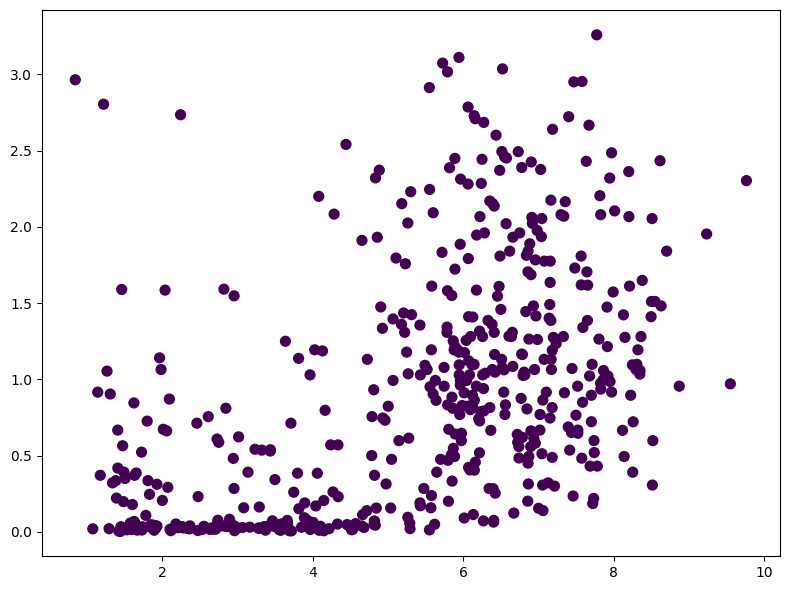

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

planets = sns.load_dataset("planets").dropna(subset=["orbital_period", "mass"])
X = planets[["orbital_period", "mass"]].values
X = np.log1p(X)

kmeans = KMeans(n_clusters=1, random_state=42).fit(X)
labels = kmeans.labels_

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap="viridis", s=50)
plt.tight_layout()
plt.show()
